In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [2]:
pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
concrete_compressive_strength = fetch_ucirepo(id=165) 
  
# data (as pandas dataframes) 
X = concrete_compressive_strength.data.features 
y = concrete_compressive_strength.data.targets 
  
# metadata 
print(concrete_compressive_strength.metadata) 
  
# variable information 
print(concrete_compressive_strength.variables) 


{'uci_id': 165, 'name': 'Concrete Compressive Strength', 'repository_url': 'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength', 'data_url': 'https://archive.ics.uci.edu/static/public/165/data.csv', 'abstract': 'Concrete is the most important material in civil engineering. The concrete compressive strength is a highly nonlinear function of age and ingredients. ', 'area': 'Physics and Chemistry', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 1030, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Concrete compressive strength'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sun Feb 11 2024', 'dataset_doi': '10.24432/C5PK67', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 383, 'type': 'NATIVE', 'title': 'Modeling of strength of high-performance concrete using artificial neural networks', 'authors': 'I. Yeh', 'venue': 'C

2. Load the Dataset

In [9]:
df = pd.read_csv("C:/Users/natar/OneDrive/Desktop/mltp/dataset")

print("First 5 rows:")
print(df.head())

First 5 rows:
   Cement  BlastFurnaceSlag  FlyAsh  Water  Superplasticizer  CoarseAggregate  \
0   540.0               0.0       0  162.0               2.5           1040.0   
1   540.0               0.0       0  162.0               2.5           1055.0   
2   332.5             142.5       0  228.0               0.0            932.0   
3   332.5             142.5       0  228.0               0.0            932.0   
4   198.6             132.4       0  192.0               0.0            978.4   

   FineAggregate  Age  Strength  
0          676.0   28     79.99  
1          676.0   28     61.89  
2          594.0  270     40.27  
3          594.0  365     41.05  
4          825.5  360     44.30  


3.EDA

In [11]:
print("Shape of dataset:", df.shape)

print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

Shape of dataset: (20, 9)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Cement            20 non-null     float64
 1   BlastFurnaceSlag  20 non-null     float64
 2   FlyAsh            20 non-null     int64  
 3   Water             20 non-null     float64
 4   Superplasticizer  20 non-null     float64
 5   CoarseAggregate   20 non-null     float64
 6   FineAggregate     20 non-null     float64
 7   Age               20 non-null     int64  
 8   Strength          20 non-null     float64
dtypes: float64(7), int64(2)
memory usage: 1.5 KB
None

Summary Statistics:
           Cement  BlastFurnaceSlag  FlyAsh       Water  Superplasticizer  \
count   20.000000         20.000000    20.0   20.000000         20.000000   
mean   341.490000         98.385000     0.0  212.275000          1.075000   
std    117.340189         69.7015

4.data visualization


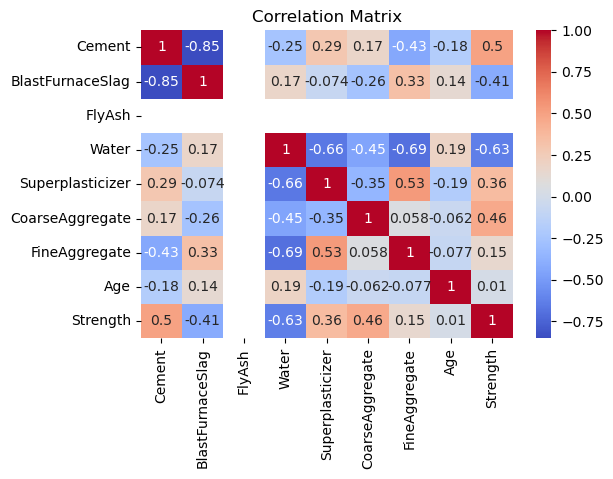

In [13]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

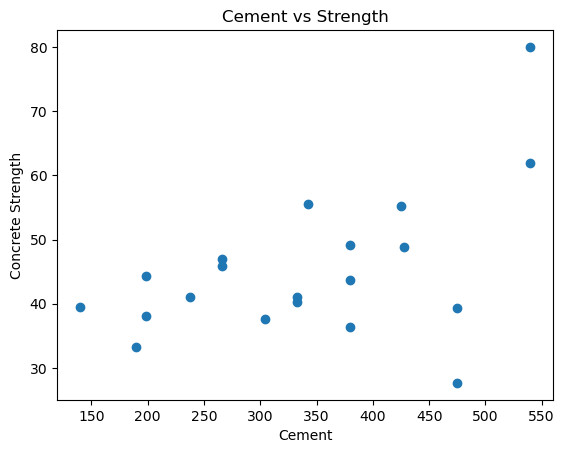

In [15]:
plt.scatter(df['Cement'], df['Strength'])
plt.xlabel("Cement")
plt.ylabel("Concrete Strength")
plt.title("Cement vs Strength")
plt.show()

5. Data Cleaning & Transformation

In [16]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Cement              0
BlastFurnaceSlag    0
FlyAsh              0
Water               0
Superplasticizer    0
CoarseAggregate     0
FineAggregate       0
Age                 0
Strength            0
dtype: int64


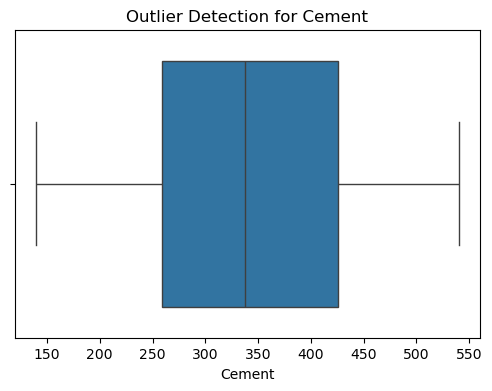

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Cement'])
plt.title("Outlier Detection for Cement")
plt.show()

In [21]:
scaler = StandardScaler()

X = df.drop('Strength', axis=1)
y = df['Strength']

X_scaled = scaler.fit_transform(X)

6. Simple Linear Regression

In [24]:
X_simple = df[['Cement']]
y = df['Strength']
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

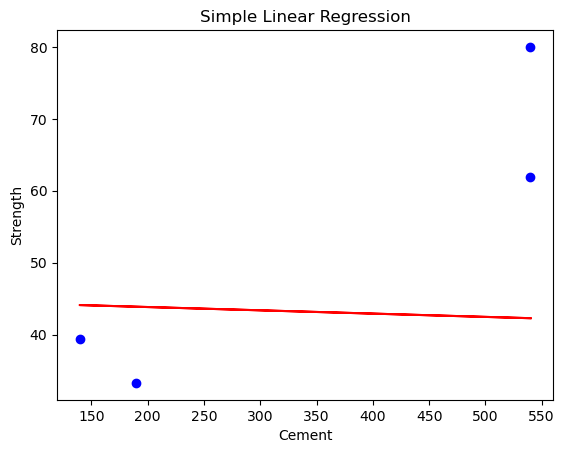

R2 Score: -0.40708429690422254
MAE: 18.146710559184143
MSE: 484.84909683701073
RMSE: 22.019289199177404


In [25]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red')
plt.xlabel("Cement")
plt.ylabel("Strength")
plt.title("Simple Linear Regression")
plt.show()


r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

7. Multiple Linear Regression

In [26]:
X = df.drop('Strength', axis=1)
y = df['Strength']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Multiple Linear Regression Results")
print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

Multiple Linear Regression Results
R2 Score: -5.022595961088677
MAE: 34.8133830624749
MSE: 2075.248951873447
RMSE: 45.5549004155804


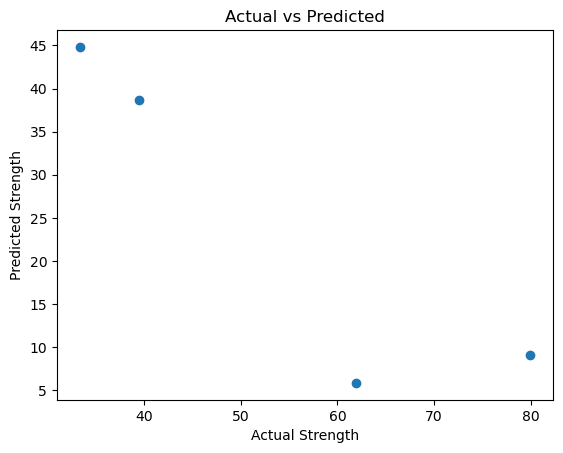

In [27]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs Predicted")
plt.show()